# Reto-test Python for Data

Global Importaciones - Base de datos Northwind

In [1]:
import pandas as pd
import psycopg2
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

## Conexión con Postgres

In [2]:
conn = psycopg2.connect(
    host="localhost",
    database="northwind",
    user="postgres",
    password="admin",
    port="5433"
)

## Ejercicio 1. Familiarizarse con la Base de Datos

In [3]:
query = """
SELECT table_name
FROM information_schema.tables
WHERE table_schema = 'public'
"""
pd.read_sql(query, conn)

,table_name
0,us_states
1,customers
2,orders
3,employees
4,shippers
5,products
6,order_details
7,categories
8,suppliers
9,region


La base de datos tiene 14 tablas. Las más importantes son:
- **orders**: los pedidos. Se relaciona con customers, employees y shippers.
- **order_details**: los productos de cada pedido. Se relaciona con orders y products.
- **products**: los productos. Se relaciona con categories y suppliers.
- **employees**: los empleados. La columna reports_to indica quién es su jefe.

## Ejercicio 2. Primeras consultas

¿Cuántos empleados tenemos?

In [4]:
query = "SELECT employee_id, first_name, last_name, city, country FROM employees"
empleados = pd.read_sql(query, conn)
print(len(empleados))
empleados

9


,employee_id,first_name,last_name,city,country
0,1,Nancy,Davolio,Seattle,USA
1,2,Andrew,Fuller,Tacoma,USA
2,3,Janet,Leverling,Kirkland,USA
3,4,Margaret,Peacock,Redmond,USA
4,5,Steven,Buchanan,London,UK
5,6,Michael,Suyama,London,UK
6,7,Robert,King,London,UK
7,8,Laura,Callahan,Seattle,USA
8,9,Anne,Dodsworth,London,UK


¿Qué productos tenemos?

In [5]:
query = """
SELECT product_id, supplier_id, product_name, unit_price, units_in_stock, units_on_order, discontinued
FROM products
"""
productos = pd.read_sql(query, conn)
productos

,product_id,supplier_id,product_name,unit_price,units_in_stock,units_on_order,discontinued
0,1,8,Chai,18.00,39,0,1
1,2,1,Chang,19.00,17,40,1
2,3,1,Aniseed Syrup,10.00,13,70,0
3,4,2,Chef Anton's Cajun Seasoning,22.00,53,0,0
4,5,2,Chef Anton's Gumbo Mix,21.35,0,0,1
...,...,...,...,...,...,...,...
72,73,17,Röd Kaviar,15.00,101,0,0
73,74,4,Longlife Tofu,10.00,4,20,0
74,75,12,Rhönbräu Klosterbier,7.75,125,0,0
75,76,23,Lakkalikööri,18.00,57,0,0


¿Tenemos productos descontinuados?

In [6]:
query = "SELECT product_name, units_in_stock FROM products WHERE discontinued = 1"
pd.read_sql(query, conn)

,product_name,units_in_stock
0,Chai,39
1,Chang,17
2,Chef Anton's Gumbo Mix,0
3,Mishi Kobe Niku,29
4,Alice Mutton,0
5,Guaraná Fantástica,20
6,Rössle Sauerkraut,26
7,Thüringer Rostbratwurst,0
8,Singaporean Hokkien Fried Mee,26
9,Perth Pasties,0


¿Qué proveedores tenemos?

In [7]:
query = "SELECT supplier_id, company_name, city, country FROM suppliers"
pd.read_sql(query, conn)

,supplier_id,company_name,city,country
0,1,Exotic Liquids,London,UK
1,2,New Orleans Cajun Delights,New Orleans,USA
2,3,Grandma Kelly's Homestead,Ann Arbor,USA
3,4,Tokyo Traders,Tokyo,Japan
4,5,Cooperativa de Quesos 'Las Cabras',Oviedo,Spain
5,6,Mayumi's,Osaka,Japan
6,7,"Pavlova, Ltd.",Melbourne,Australia
7,8,"Specialty Biscuits, Ltd.",Manchester,UK
8,9,PB Knäckebröd AB,Göteborg,Sweden
9,10,Refrescos Americanas LTDA,Sao Paulo,Brazil


¿Qué pedidos hemos tenido?

In [8]:
query = """
SELECT order_id, customer_id, ship_via, order_date, required_date, shipped_date
FROM orders
"""
pd.read_sql(query, conn)

,order_id,customer_id,ship_via,order_date,required_date,shipped_date
0,10248,VINET,3,1996-07-04,1996-08-01,1996-07-16
1,10249,TOMSP,1,1996-07-05,1996-08-16,1996-07-10
2,10250,HANAR,2,1996-07-08,1996-08-05,1996-07-12
3,10251,VICTE,1,1996-07-08,1996-08-05,1996-07-15
4,10252,SUPRD,2,1996-07-09,1996-08-06,1996-07-11
...,...,...,...,...,...,...
825,11073,PERIC,2,1998-05-05,1998-06-02,None
826,11074,SIMOB,2,1998-05-06,1998-06-03,None
827,11075,RICSU,2,1998-05-06,1998-06-03,None
828,11076,BONAP,2,1998-05-06,1998-06-03,None


¿Cuántos pedidos hemos tenido?

In [9]:
query = "SELECT COUNT(*) FROM orders"
pd.read_sql(query, conn)

,count
0,830


¿Cuántos clientes tenemos?

In [10]:
query = "SELECT customer_id, company_name, city, country FROM customers"
clientes = pd.read_sql(query, conn)
print(len(clientes))
clientes

91


,customer_id,company_name,city,country
0,ALFKI,Alfreds Futterkiste,Berlin,Germany
1,ANATR,Ana Trujillo Emparedados y helados,México D.F.,Mexico
2,ANTON,Antonio Moreno Taquería,México D.F.,Mexico
3,AROUT,Around the Horn,London,UK
4,BERGS,Berglunds snabbköp,Luleå,Sweden
...,...,...,...,...
86,WARTH,Wartian Herkku,Oulu,Finland
87,WELLI,Wellington Importadora,Resende,Brazil
88,WHITC,White Clover Markets,Seattle,USA
89,WILMK,Wilman Kala,Helsinki,Finland


¿Con qué empresas de transporte trabajamos?

In [11]:
query = "SELECT shipper_id, company_name FROM shippers"
pd.read_sql(query, conn)

,shipper_id,company_name
0,1,Speedy Express
1,2,United Package
2,3,Federal Shipping
3,4,Alliance Shippers
4,5,UPS
5,6,DHL


¿Cómo son las relaciones de reporte entre los empleados?

In [12]:
query = """
SELECT e.first_name, e.last_name, e.title, j.first_name AS jefe_nombre, j.last_name AS jefe_apellido
FROM employees e
LEFT JOIN employees j ON e.reports_to = j.employee_id
"""
pd.read_sql(query, conn)

,first_name,last_name,title,jefe_nombre,jefe_apellido
0,Nancy,Davolio,Sales Representative,Andrew,Fuller
1,Andrew,Fuller,"Vice President, Sales",NaN,NaN
2,Janet,Leverling,Sales Representative,Andrew,Fuller
3,Margaret,Peacock,Sales Representative,Andrew,Fuller
4,Steven,Buchanan,Sales Manager,Andrew,Fuller
5,Michael,Suyama,Sales Representative,Steven,Buchanan
6,Robert,King,Sales Representative,Steven,Buchanan
7,Laura,Callahan,Inside Sales Coordinator,Andrew,Fuller
8,Anne,Dodsworth,Sales Representative,Steven,Buchanan


Andrew Fuller es el jefe de todos. Steven Buchanan es jefe de 3 empleados de Londres.

## Ejercicio 3. Análisis de la empresa

In [13]:
# pedidos y clientes
query = """
SELECT o.*, c.company_name, c.country
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
"""
df_pedidos = pd.read_sql(query, conn)
df_pedidos.head()

,order_id,customer_id,employee_id,order_date,required_date,shipped_date,ship_via,freight,ship_name,ship_address,ship_city,ship_region,ship_postal_code,ship_country,company_name,country
0,10248,VINET,5,1996-07-04,1996-08-01,1996-07-16,3,32.38,Vins et alcools Chevalier,59 rue de l'Abbaye,Reims,NaN,51100,France,Vins et alcools Chevalier,France
1,10249,TOMSP,6,1996-07-05,1996-08-16,1996-07-10,1,11.61,Toms Spezialitäten,Luisenstr. 48,Münster,NaN,44087,Germany,Toms Spezialitäten,Germany
2,10250,HANAR,4,1996-07-08,1996-08-05,1996-07-12,2,65.83,Hanari Carnes,"Rua do Paço, 67",Rio de Janeiro,RJ,05454-876,Brazil,Hanari Carnes,Brazil
3,10251,VICTE,3,1996-07-08,1996-08-05,1996-07-15,1,41.34,Victuailles en stock,"2, rue du Commerce",Lyon,NaN,69004,France,Victuailles en stock,France
4,10252,SUPRD,4,1996-07-09,1996-08-06,1996-07-11,2,51.30,Suprêmes délices,"Boulevard Tirou, 255",Charleroi,NaN,B-6000,Belgium,Suprêmes délices,Belgium


In [14]:
# productos, proveedores y detalles de pedidos
query = """
SELECT od.*, p.product_name, p.units_in_stock, p.units_on_order, s.company_name AS proveedor
FROM order_details od
JOIN products p ON od.product_id = p.product_id
JOIN suppliers s ON p.supplier_id = s.supplier_id
"""
df_productos = pd.read_sql(query, conn)
df_productos.head()

,order_id,product_id,unit_price,quantity,discount,product_name,units_in_stock,units_on_order,proveedor
0,10248,11,14.0,12,0.0,Queso Cabrales,22,30,Cooperativa de Quesos 'Las Cabras'
1,10248,42,9.8,10,0.0,Singaporean Hokkien Fried Mee,26,0,Leka Trading
2,10248,72,34.8,5,0.0,Mozzarella di Giovanni,14,0,Formaggi Fortini s.r.l.
3,10249,14,18.6,9,0.0,Tofu,35,0,Mayumi's
4,10249,51,42.4,40,0.0,Manjimup Dried Apples,20,0,"G'day, Mate"


### Evolución de los pedidos

In [15]:
query = """
SELECT EXTRACT(YEAR FROM order_date) AS anio, EXTRACT(MONTH FROM order_date) AS mes, COUNT(*) AS pedidos
FROM orders
GROUP BY anio, mes
ORDER BY anio, mes
"""
pedidos_mes = pd.read_sql(query, conn)
pedidos_mes["fecha"] = pedidos_mes["anio"].astype(int).astype(str) + "-" + pedidos_mes["mes"].astype(int).astype(str)
pedidos_mes

,anio,mes,pedidos,fecha
0,1996.0,7.0,22,1996-7
1,1996.0,8.0,25,1996-8
2,1996.0,9.0,23,1996-9
3,1996.0,10.0,26,1996-10
4,1996.0,11.0,25,1996-11
5,1996.0,12.0,31,1996-12
6,1997.0,1.0,33,1997-1
7,1997.0,2.0,29,1997-2
8,1997.0,3.0,30,1997-3
9,1997.0,4.0,31,1997-4


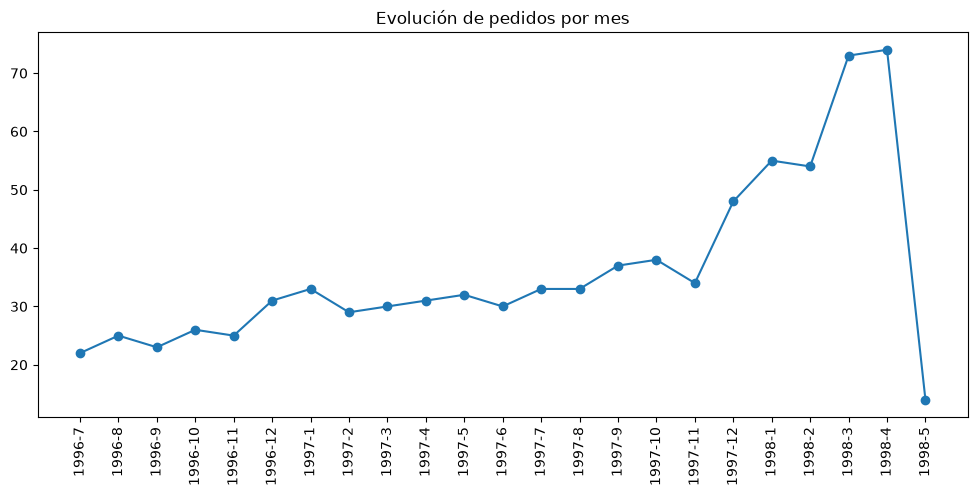

In [16]:
plt.figure(figsize=(12, 5))
plt.plot(pedidos_mes["fecha"], pedidos_mes["pedidos"], marker="o")
plt.title("Evolución de pedidos por mes")
plt.xticks(rotation=90)
plt.show()

Los pedidos aumentan con el tiempo, sobre todo en 1998. En mayo de 1998 bajan porque los datos acaban el día 6.

### Pedidos por país y continente

In [17]:
pedidos_pais = df_pedidos["country"].value_counts().reset_index()
pedidos_pais.columns = ["pais", "pedidos"]

continentes = {'Europe': ['Austria', 'Belgium', 'Denmark', 'Finland', 'France',
'Germany', 'Ireland', 'Italy', 'Norway', 'Poland', 'Portugal', 'Spain', 'Sweden',
'Switzerland', 'UK'],
'America': ['Argentina', 'Brazil', 'Canada', 'Mexico', 'USA', 'Venezuela']}

def continente(pais):
    if pais in continentes["Europe"]:
        return "Europe"
    else:
        return "America"

pedidos_pais["continente"] = pedidos_pais["pais"].apply(continente)
pedidos_pais

,pais,pedidos,continente
0,Germany,122,Europe
1,USA,122,America
2,Brazil,83,America
3,France,77,Europe
4,UK,56,Europe
5,Venezuela,46,America
6,Austria,40,Europe
7,Sweden,37,Europe
8,Canada,30,America
9,Mexico,28,America


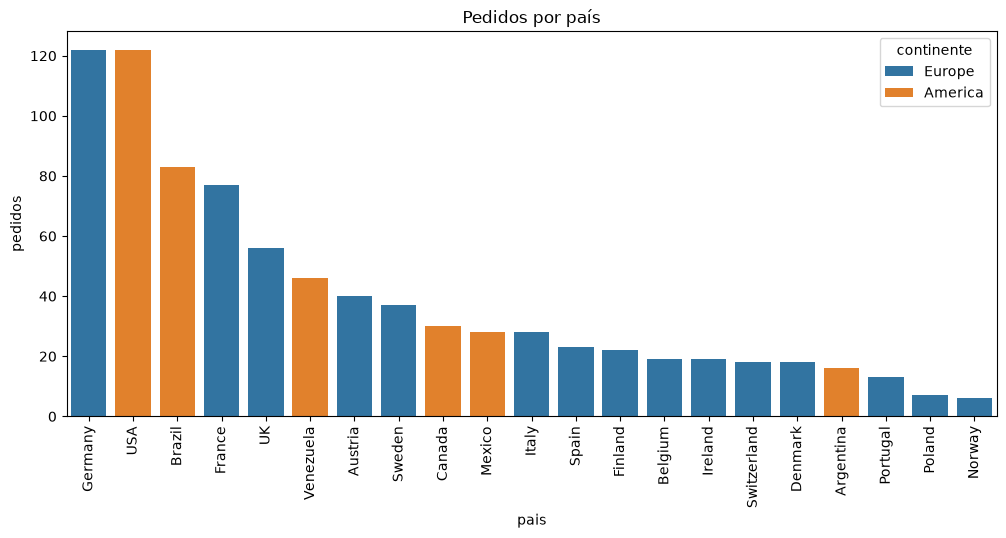

In [18]:
plt.figure(figsize=(12, 5))
sns.barplot(data=pedidos_pais, x="pais", y="pedidos", hue="continente")
plt.xticks(rotation=90)
plt.title("Pedidos por país")
plt.show()

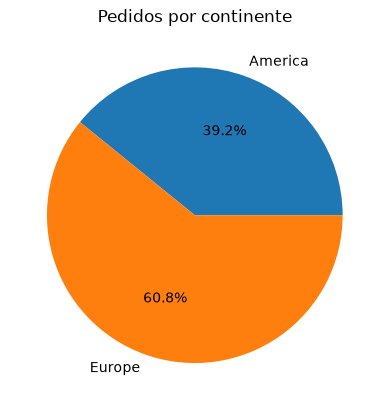

In [19]:
pedidos_continente = pedidos_pais.groupby("continente")["pedidos"].sum()
plt.pie(pedidos_continente, labels=pedidos_continente.index, autopct="%1.1f%%")
plt.title("Pedidos por continente")
plt.show()

Alemania y USA son los países con más pedidos. Europa tiene más pedidos que América.

### Retrasos por compañía de transporte

In [20]:
query = """
SELECT o.order_id, s.company_name, o.required_date, o.shipped_date,
       o.shipped_date - o.required_date AS dias_retraso
FROM orders o
JOIN shippers s ON o.ship_via = s.shipper_id
"""
envios = pd.read_sql(query, conn)
envios.head()

,order_id,company_name,required_date,shipped_date,dias_retraso
0,10248,Federal Shipping,1996-08-01,1996-07-16,-16.0
1,10249,Speedy Express,1996-08-16,1996-07-10,-37.0
2,10250,United Package,1996-08-05,1996-07-12,-24.0
3,10251,Speedy Express,1996-08-05,1996-07-15,-21.0
4,10252,United Package,1996-08-06,1996-07-11,-26.0


In [21]:
# pedidos con retraso por transportista
envios[envios["dias_retraso"] > 0]["company_name"].value_counts()

company_name
United Package      16
Speedy Express      12
Federal Shipping     9
Name: count, dtype: int64

In [22]:
# pedidos sin fecha de llegada por transportista
envios[envios["shipped_date"].isnull()]["company_name"].value_counts()

company_name
United Package      11
Federal Shipping     6
Speedy Express       4
Name: count, dtype: int64

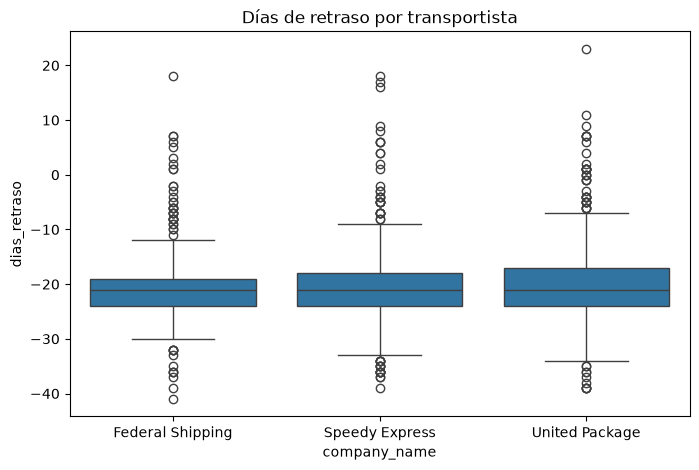

In [23]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=envios, x="company_name", y="dias_retraso")
plt.title("Días de retraso por transportista")
plt.show()

Las tres compañías tienen un rango intercuartílico muy parecido y pocos retrasos. United Package tiene algo más de retrasos y pedidos sin llegada, pero también hace más envíos. No parece que el transportista sea la causa.

### Precio medio del pedido por país

In [24]:
df_productos["total"] = df_productos["unit_price"] * df_productos["quantity"] * (1 - df_productos["discount"])
total_pedido = df_productos.groupby("order_id")["total"].sum().reset_index()
total_pedido = total_pedido.merge(df_pedidos[["order_id", "country"]], on="order_id")
precio_pais = total_pedido.groupby("country")["total"].mean().sort_values(ascending=False)
precio_pais

country
Austria        3200.095963
Ireland        2630.521316
USA            2012.988611
Germany        1887.578963
Denmark        1814.501250
Belgium        1780.255526
Switzerland    1760.703278
Canada         1673.209667
Sweden         1472.841622
Brazil         1288.262367
Venezuela      1235.013674
France         1056.601591
UK             1053.059107
Norway          955.858333
Portugal        882.489423
Finland         855.002386
Mexico          842.217054
Spain           781.878261
Italy           563.219821
Argentina       507.443750
Poland          504.564286
Name: total, dtype: float64

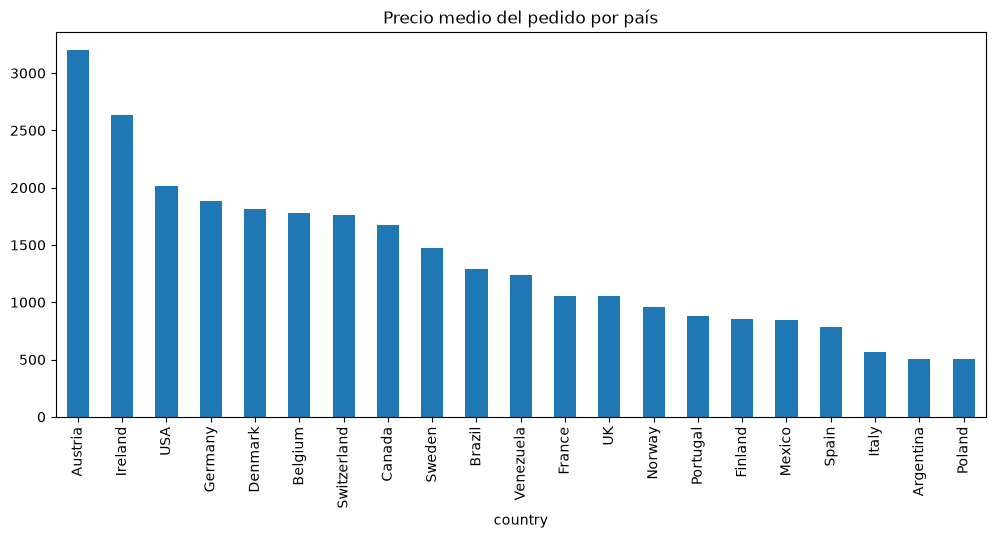

In [25]:
plt.figure(figsize=(12, 5))
precio_pais.plot(kind="bar")
plt.title("Precio medio del pedido por país")
plt.show()

Austria e Irlanda tienen el precio medio más alto. Italia, Argentina y Polonia el más bajo.

### Clientes sin pedidos

In [26]:
query = """
SELECT c.customer_id, c.company_name
FROM customers c
LEFT JOIN orders o ON c.customer_id = o.customer_id
WHERE o.order_id IS NULL
"""
sin_pedidos = pd.read_sql(query, conn)
print(sin_pedidos)
print("Porcentaje:", round(len(sin_pedidos) / len(clientes) * 100, 2), "%")

  customer_id                          company_name
0       PARIS                     Paris spécialités
1       FISSA  FISSA Fabrica Inter. Salchichas S.A.
Porcentaje: 2.2 %


Hay 2 clientes sin pedidos, un 2.2% del total.

### Productos más demandados y reestock

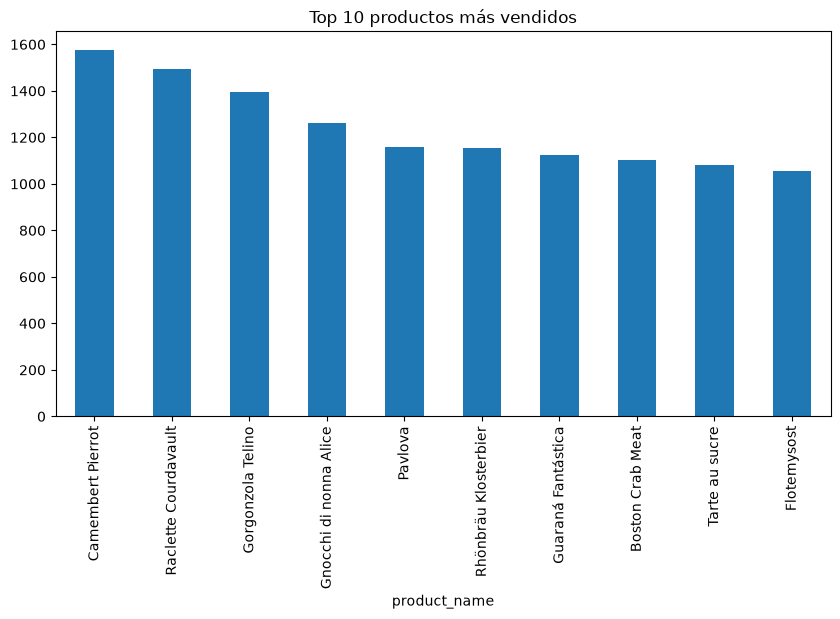

In [27]:
mas_vendidos = df_productos.groupby("product_name")["quantity"].sum().sort_values(ascending=False).head(10)
mas_vendidos.plot(kind="bar", figsize=(10, 5))
plt.title("Top 10 productos más vendidos")
plt.show()

In [28]:
reestock = productos[(productos["units_in_stock"] <= 20) & (productos["units_on_order"] == 0) & (productos["discontinued"] == 0)]
reestock[["product_name", "units_in_stock", "units_on_order"]]

,product_name,units_in_stock,units_on_order
6,Uncle Bob's Organic Dried Pears,15,0
7,Northwoods Cranberry Sauce,6,0
25,Gumbär Gummibärchen,15,0
29,Nord-Ost Matjeshering,10,0
34,Steeleye Stout,20,0
37,Côte de Blaye,17,0
50,Manjimup Dried Apples,20,0
59,Camembert Pierrot,19,0
61,Tarte au sucre,17,0
71,Mozzarella di Giovanni,14,0


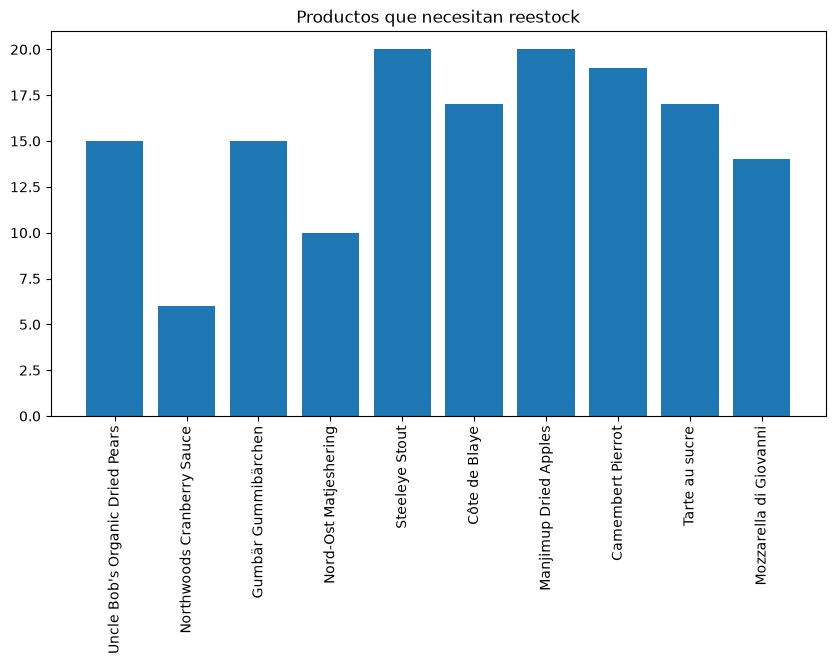

In [29]:
plt.figure(figsize=(10, 5))
plt.bar(reestock["product_name"], reestock["units_in_stock"])
plt.xticks(rotation=90)
plt.title("Productos que necesitan reestock")
plt.show()

Hay 10 productos que necesitan reestock. Camembert Pierrot y Tarte au sucre son los más urgentes porque se venden mucho.

## Ejercicio 4. Queries Avanzadas

Última vez que se pidió un producto de cada categoría

In [30]:
query = """
SELECT c.category_name, MAX(o.order_date) AS ultimo_pedido
FROM categories c
JOIN products p ON c.category_id = p.category_id
JOIN order_details od ON p.product_id = od.product_id
JOIN orders o ON od.order_id = o.order_id
GROUP BY c.category_name
"""
pd.read_sql(query, conn)

,category_name,ultimo_pedido
0,Beverages,1998-05-06
1,Produce,1998-05-06
2,Condiments,1998-05-06
3,Grains/Cereals,1998-05-06
4,Meat/Poultry,1998-05-06
5,Confections,1998-05-06
6,Dairy Products,1998-05-06
7,Seafood,1998-05-06


Productos que nunca se han vendido por su precio original

In [31]:
query = """
SELECT product_id, product_name
FROM products
WHERE product_id NOT IN (
    SELECT od.product_id
    FROM order_details od
    JOIN products p ON od.product_id = p.product_id
    WHERE od.unit_price = p.unit_price
)
"""
pd.read_sql(query, conn)

,product_id,product_name
0,15,Genen Shouyu


Productos de la categoría Confections

In [32]:
query = """
SELECT p.product_id, p.product_name, p.category_id
FROM products p
JOIN categories c ON p.category_id = c.category_id
WHERE c.category_name = 'Confections'
"""
pd.read_sql(query, conn)

,product_id,product_name,category_id
0,16,Pavlova,3
1,19,Teatime Chocolate Biscuits,3
2,20,Sir Rodney's Marmalade,3
3,21,Sir Rodney's Scones,3
4,25,NuNuCa Nuß-Nougat-Creme,3
5,26,Gumbär Gummibärchen,3
6,27,Schoggi Schokolade,3
7,47,Zaanse koeken,3
8,48,Chocolade,3
9,49,Maxilaku,3


Proveedores con todos sus productos descontinuados

In [33]:
query = """
SELECT s.supplier_id, s.company_name
FROM suppliers s
JOIN products p ON s.supplier_id = p.supplier_id
GROUP BY s.supplier_id, s.company_name
HAVING MIN(p.discontinued) = 1
"""
pd.read_sql(query, conn)

,supplier_id,company_name
0,10,Refrescos Americanas LTDA


Clientes que compraron más de 30 Chai en un pedido

In [34]:
query = """
SELECT DISTINCT c.customer_id, c.company_name
FROM customers c
JOIN orders o ON c.customer_id = o.customer_id
JOIN order_details od ON o.order_id = od.order_id
JOIN products p ON od.product_id = p.product_id
WHERE p.product_name = 'Chai' AND od.quantity > 30
"""
pd.read_sql(query, conn)

,customer_id,company_name
0,BERGS,Berglunds snabbköp
1,BOTTM,Bottom-Dollar Markets
2,LEHMS,Lehmanns Marktstand
3,LINOD,LINO-Delicateses
4,QUICK,QUICK-Stop
5,SAVEA,Save-a-lot Markets
6,SEVES,Seven Seas Imports


Clientes con carga total mayor de 1000

In [35]:
query = """
SELECT c.customer_id, c.company_name, SUM(o.freight) AS carga_total
FROM customers c
JOIN orders o ON c.customer_id = o.customer_id
GROUP BY c.customer_id, c.company_name
HAVING SUM(o.freight) > 1000
"""
pd.read_sql(query, conn)

,customer_id,company_name,carga_total
0,QUEEN,Queen Cozinha,1982.7000
1,RATTC,Rattlesnake Canyon Grocery,2134.2102
2,FRANK,Frankenversand,1403.4398
3,LEHMS,Lehmanns Marktstand,1017.0300
4,QUICK,QUICK-Stop,5605.6304
5,HUNGO,Hungry Owl All-Night Grocers,2755.2400
6,MEREP,Mère Paillarde,1394.2200
7,BONAP,Bon app',1357.8701
8,BERGS,Berglunds snabbköp,1559.5199
9,FOLKO,Folk och fä HB,1678.0802


Ciudades con 5 o más empleados

In [36]:
query = """
SELECT city, COUNT(*) AS empleados
FROM employees
GROUP BY city
HAVING COUNT(*) >= 5
"""
pd.read_sql(query, conn)

,city,empleados


No hay ninguna ciudad con 5 o más empleados. La que más tiene es Londres con 4.